In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities import extractor
import uproot
import awkward as ak    

x_MH25=extractor("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH25_LH_2017.root", "Events")


file=uproot.open("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH25_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]

#Filtriamo i dati

mask = ak.flatten(Fatjet_isMatchedWithA) == 1
x_filtered = x_MH25[mask]



/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/riccardo/anaconda3/envs/rootnev/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "
/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


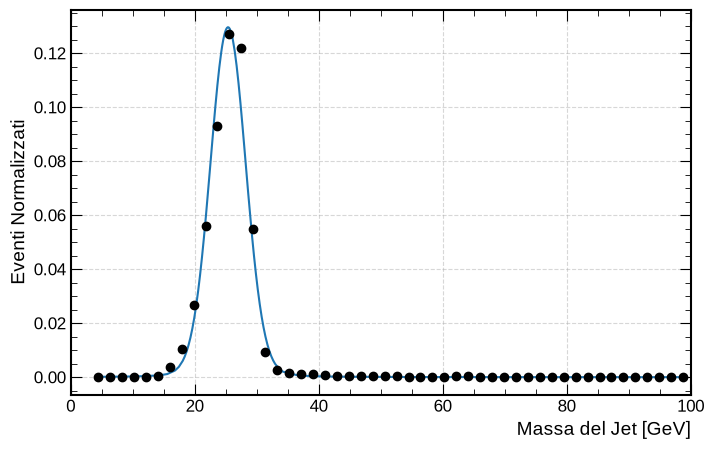

In [ ]:
from scipy.special import voigt_profile
from scipy.optimize import curve_fit
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


x_plot=list(x_filtered)
x_plot.sort()

x_easy=[x for x in x_plot if 0<x<100]

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_easy) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_easy) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=50, sigma=5, gamma=1)
m_voigt.limits["mu"]= (10, 40)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.migrad()

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fix, ax= plt.subplots(figsize=(8, 5))



m_voigt.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel("Massa del Jet [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Voigt_Minuit_25', bbox_inches='tight')


In [ ]:
import pickle

with open("fit_results.pkl", "wb") as f:
    pickle.dump(m_voigt.values, f)

print(m_voigt.values)

print(m_voigt.errors)
print(m_voigt.parameters)

<ValueView norm=0.9543014556838152 mu=25.386269452999606 sigma=2.774403498703792 gamma=0.2006061236569035>
<ErrorView norm=0.004148821580776669 mu=0.014792115634639558 sigma=0.013565863200996287 gamma=0.00832285214782491>
('norm', 'mu', 'sigma', 'gamma')


In [ ]:
fit_MH25_values={}
fit_MH25_errors={}

fit_values={'MH25': fit_MH25_values,}
fit_errors={'MH25_errors': fit_MH25_errors}



for param in m_voigt.parameters:
    fit_MH25_values[param] = m_voigt.values[param]

for error in m_voigt.parameters:    #Qui non ho capito come fa a capire che deve estarre gli errori 
    fit_MH25_errors[error] = m_voigt.errors[error]

print(fit_MH25_values)
print(fit_MH25_errors)

import json
#QUi sono andato di metodo oragutang, ho deciso di voler fare 2 file separati peer errori e valori 
#Ho tenuto lo stesso quello con tutti i valori, casomai cambiassi idea

with open("fit_results.json", "r") as f:
    results=json.load(f)

with open("fit_values.json", "r") as g:
    values=json.load(g) 

with open("fit_errors.json", "r") as h:
    errors=json.load(h)


results["MH25"]=fit_MH25_values
results["MH25_errors"]=fit_MH25_errors

with open("fit_results.json", "w") as f:
    json.dump(results, f, indent=1)

values["MH25"]=fit_MH25_values
with open("fit_values.json", "w") as g:
    json.dump(values, g, indent=1)  

errors["MH25_errors"]=fit_MH25_errors
with open("fit_errors.json", "w") as h:
    json.dump(errors, h, indent=1)  





{'norm': 0.9543014556838152, 'mu': 25.386269452999606, 'sigma': 2.774403498703792, 'gamma': 0.2006061236569035}
{'norm': 0.004148821580776669, 'mu': 0.014792115634639558, 'sigma': 0.013565863200996287, 'gamma': 0.00832285214782491}
